In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
adult_df=pd.read_csv(r"C:\Users\H P\Downloads\adult_data.csv",header=None)
adult_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
adult_df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                    'marital_status', 'occupation', 'relationship',
                    'race', 'sex', 'capital_gain', 'capital_loss',
                    'hours_per_week', 'native_country', 'income']
 
adult_df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
adult_df.shape

(32561, 15)

In [5]:
adult_df.info()     # nature of data (structural data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
adult_df.describe(include='all')     # statical summary in the data

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


# Pre processing the data:

In [7]:
# create a copy of the dataframe
adult_df_rev=pd.DataFrame.copy(adult_df)
adult_df_rev

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [8]:
adult_df_rev.duplicated().sum()

np.int64(24)

In [9]:
adult_df_rev[adult_df_rev.duplicated()]

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,?,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [10]:
adult_df_rev.drop_duplicates(inplace=True,keep='first')
adult_df_rev.shape

(32537, 15)

In [11]:
adult_df_rev.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [12]:
adult_df_rev.drop(['education_num','fnlwgt','marital_status'],axis=1,inplace=True)
adult_df_rev.shape

(32537, 12)

In [13]:
for i in adult_df_rev.columns:
    print({i:adult_df_rev[i].unique()})

{'age': array([39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 30, 23, 32, 40, 34, 25, 43,
       54, 35, 59, 56, 19, 20, 45, 22, 48, 21, 24, 57, 44, 41, 29, 18, 47,
       46, 36, 79, 27, 67, 33, 76, 17, 55, 61, 70, 64, 71, 68, 66, 51, 58,
       26, 60, 90, 75, 65, 77, 62, 63, 80, 72, 74, 69, 73, 81, 78, 88, 82,
       83, 84, 85, 86, 87])}
{'workclass': array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)}
{'education': array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)}
{'occupation': array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',


In [14]:
adult_df_rev.replace(' ?',np.nan,inplace=True)

In [15]:
adult_df_rev.isnull().sum()/len(adult_df_rev)*100

age               0.000000
workclass         5.642807
education         0.000000
occupation        5.664321
relationship      0.000000
race              0.000000
sex               0.000000
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    0.000000
native_country    1.788733
income            0.000000
dtype: float64

In [16]:
adult_df_rev.workclass.value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [17]:
adult_df_rev.workclass.mode()[0]

' Private'

In [18]:
adult_df_rev.occupation.mode()[0]

' Prof-specialty'

In [19]:
adult_df_rev.native_country.mode()[0]

' United-States'

In [20]:
 # adult_df_rev['workclass'].fillna(adult_df_rev.workclass.mode()[0])

In [21]:
# replace the missing values with mode values
for value in ['workclass','occupation','native_country']:
    adult_df_rev[value].fillna(adult_df_rev[value].mode()[0],inplace=True)

In [22]:
adult_df_rev.isnull().sum()

age               0
workclass         0
education         0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [23]:
adult_df_rev.shape

(32537, 12)

In [24]:
adult_df_rev.dtypes

age                int64
workclass         object
education         object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

# Dummy variables using pd.get_dummies()

In [25]:
adult_df_rev_new=pd.get_dummies(adult_df_rev)
adult_df_rev_new.head()

,age,capital_gain,capital_loss,hours_per_week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia,income_ <=50K,income_ >50K
0,39,2174,0,40,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,50,0,0,13,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False
2,38,0,0,40,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
3,53,0,0,40,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
4,28,0,0,40,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [26]:
adult_df_rev.dtypes

age                int64
workclass         object
education         object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [27]:
colname=[]
for x in adult_df_rev.columns:
    if adult_df_rev[x].dtype=='object':
        colname.append(x)
colname



['workclass',
 'education',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [28]:
# For preprocessing the data
from sklearn.preprocessing import LabelEncoder
 
le=LabelEncoder()
 
for x in colname:
    adult_df_rev[x]=le.fit_transform(adult_df_rev[x])
 
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('mapping', le_name_mapping)
    print('-----------------------')

Feature workclass
mapping {' Federal-gov': np.int64(0), ' Local-gov': np.int64(1), ' Never-worked': np.int64(2), ' Private': np.int64(3), ' Self-emp-inc': np.int64(4), ' Self-emp-not-inc': np.int64(5), ' State-gov': np.int64(6), ' Without-pay': np.int64(7)}
-----------------------
Feature education
mapping {' 10th': np.int64(0), ' 11th': np.int64(1), ' 12th': np.int64(2), ' 1st-4th': np.int64(3), ' 5th-6th': np.int64(4), ' 7th-8th': np.int64(5), ' 9th': np.int64(6), ' Assoc-acdm': np.int64(7), ' Assoc-voc': np.int64(8), ' Bachelors': np.int64(9), ' Doctorate': np.int64(10), ' HS-grad': np.int64(11), ' Masters': np.int64(12), ' Preschool': np.int64(13), ' Prof-school': np.int64(14), ' Some-college': np.int64(15)}
-----------------------
Feature occupation
mapping {' Adm-clerical': np.int64(0), ' Armed-Forces': np.int64(1), ' Craft-repair': np.int64(2), ' Exec-managerial': np.int64(3), ' Farming-fishing': np.int64(4), ' Handlers-cleaners': np.int64(5), ' Machine-op-inspct': np.int64(6), 

In [29]:
adult_df_rev.head()

,age,workclass,education,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,9,0,1,4,1,2174,0,40,38,0
1,50,5,9,3,0,4,1,0,0,13,38,0
2,38,3,11,5,1,4,1,0,0,40,38,0
3,53,3,1,5,0,2,1,0,0,40,38,0
4,28,3,9,9,5,2,0,0,0,40,4,0


In [30]:
data={'Gender':['Female','Male','Female'],'Colours':['Red','Blue','Yellow']}
df=pd.DataFrame(data)
df.head()

,Gender,Colours
0,Female,Red
1,Male,Blue
2,Female,Yellow


In [31]:
le_gender=LabelEncoder()
df['Gender']=le_gender.fit_transform(df['Gender'])
df.head()

,Gender,Colours
0,0,Red
1,1,Blue
2,0,Yellow


In [32]:
le_Colours=LabelEncoder()
df['Colours']=le_Colours.fit_transform(df['Colours'])
df.head()


,Gender,Colours
0,0,1
1,1,0
2,0,2


In [33]:
df['colours']=le_Colours.inverse_transform(df['Colours'])
df

,Gender,Colours,colours
0,0,1,Red
1,1,0,Blue
2,0,2,Yellow


In [34]:
df['Gender']=le_gender.inverse_transform(df['Gender'])
df

,Gender,Colours,colours
0,Female,1,Red
1,Male,0,Blue
2,Female,2,Yellow


In [35]:
adult_df_rev.dtypes

age               int64
workclass         int64
education         int64
occupation        int64
relationship      int64
race              int64
sex               int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country    int64
income            int64
dtype: object

In [36]:
import seaborn as sns
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [37]:
tips=sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [38]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [39]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [40]:
tips['smoker']=tips['smoker'].map({'Yes':1,"No":0})
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,0,Sun,Dinner,2
1,10.34,1.66,Male,0,Sun,Dinner,3
2,21.01,3.50,Male,0,Sun,Dinner,3
3,23.68,3.31,Male,0,Sun,Dinner,2
4,24.59,3.61,Female,0,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,0,Sat,Dinner,3
240,27.18,2.00,Female,1,Sat,Dinner,2
241,22.67,2.00,Male,1,Sat,Dinner,2
242,17.82,1.75,Male,0,Sat,Dinner,2


In [41]:
tips['day']=tips['day'].map({'Sun':1,'Thur':5,'Friday':6,"Sat":7})
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,0,1.0,Dinner,2
1,10.34,1.66,Male,0,1.0,Dinner,3
2,21.01,3.50,Male,0,1.0,Dinner,3
3,23.68,3.31,Male,0,1.0,Dinner,2
4,24.59,3.61,Female,0,1.0,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,0,7.0,Dinner,3
240,27.18,2.00,Female,1,7.0,Dinner,2
241,22.67,2.00,Male,1,7.0,Dinner,2
242,17.82,1.75,Male,0,7.0,Dinner,2


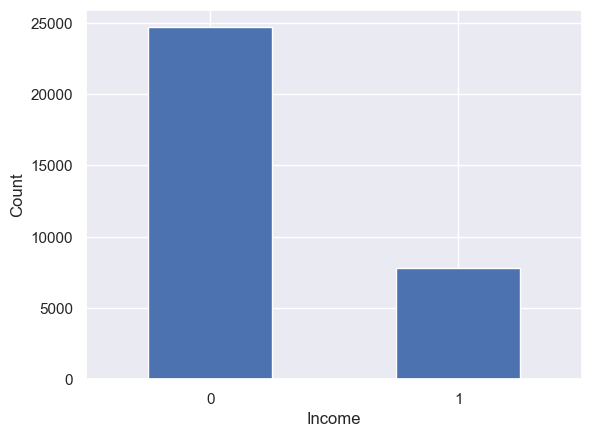

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
income_plot=adult_df_rev['income'].value_counts().plot(kind='bar')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

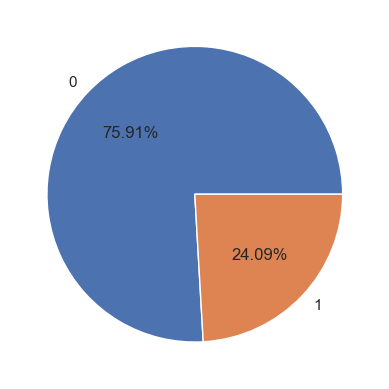

In [43]:
income_plot=adult_df_rev['income'].value_counts().plot(kind='pie',
                                                       autopct="%.2f%%")
plt.ylabel(None);

In [44]:
X=adult_df_rev.values[:,0:-1]
Y=adult_df_rev.values[:,-1]
# values will return an array wheras .iloc will return a df object
# arrays are lighter in weight which indirectly help the model to build faster

In [45]:
print(X.shape)
print(Y.shape)

(32537, 11)
(32537,)


In [46]:
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
 
scaler.fit(X)
X = scaler.transform(X)
#X=scaler.fit_transform(X)
#print(X)

In [47]:
print(X)

[[ 0.03038995  2.62344898 -0.33526611 ... -0.21674317 -0.03566374
   0.26113115]
 [ 0.8369732   1.72054053 -0.33526611 ... -0.21674317 -2.22248299
   0.26113115]
 [-0.0429358  -0.08527638  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]
 ...
 [ 1.42357919 -0.08527638  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]
 [-1.2161478  -0.08527638  0.18151876 ... -0.21674317 -1.65552985
   0.26113115]
 [ 0.9836247   0.81763207  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]]


In [48]:
Y

array([0, 0, 0, ..., 0, 0, 1])

In [49]:
Y=Y.astype(int)   # transform in the int if not in integer

# Running a Basic Model

In [50]:
from sklearn.model_selection import train_test_split
# Split the data into test and train 
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=10)

In [51]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(22775, 11)
(22775,)
(9762, 11)
(9762,)


In [52]:
from sklearn.linear_model import LogisticRegression
# create a model
classifier=LogisticRegression()
# fitting training data to the model
classifier.fit(X_train,Y_train)

LogisticRegression()

In [53]:
Y_pred_prob=classifier.predict_proba(X_test)
Y_pred_prob

array([[0.86495581, 0.13504419],
       [0.97654711, 0.02345289],
       [0.84865539, 0.15134461],
       ...,
       [0.88668023, 0.11331977],
       [0.93548984, 0.06451016],
       [0.89405115, 0.10594885]])

In [54]:
Y_pred=classifier.predict(X_test)
Y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [55]:
# print(list(zip(Y_test,Y_pred))) # this is write code

In [56]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[7098  298]
 [1627  739]]
Classification report: 
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.71      0.31      0.43      2366

    accuracy                           0.80      9762
   macro avg       0.76      0.64      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.8028068018848596


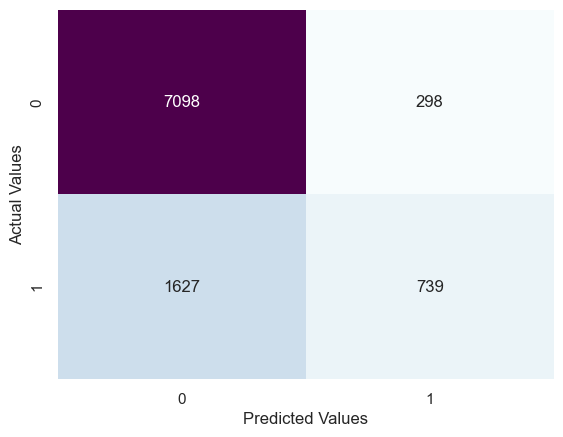

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.71      0.31      0.43      2366

    accuracy                           0.80      9762
   macro avg       0.76      0.64      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.8028068018848596


In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()
 
 
print("Classification report:")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

# Model tunning:
### Adjusting the threshold

In [58]:
# store the predicted probabilities
y_pred_prob=classifier.predict_proba(X_test)
y_pred_prob

array([[0.86495581, 0.13504419],
       [0.97654711, 0.02345289],
       [0.84865539, 0.15134461],
       ...,
       [0.88668023, 0.11331977],
       [0.93548984, 0.06451016],
       [0.89405115, 0.10594885]])

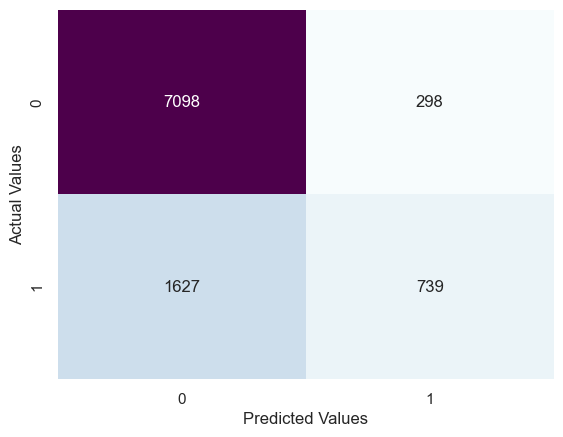

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.71      0.31      0.43      2366

    accuracy                           0.80      9762
   macro avg       0.76      0.64      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.8028068018848596


In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()
 
 
print("Classification report:")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [60]:
Y_pred_class=[]
for value in Y_pred_prob[:,1]:
    if value > 0.42:
        Y_pred_class.append(1)
    else:
        Y_pred_class.append(0)
print(Y_pred_class)

[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [61]:
for a in np.arange(0.4,0.61,0.01):
    predict_mine = np.where(y_pred_prob[:,1] > a, 1, 0)
    cfm=confusion_matrix(Y_test, predict_mine)
    total_err=cfm[0,1]+cfm[1,0]
    print("Errors at threshold ", a, ":",total_err, " , type 2 error :",
          cfm[1,0]," , type 1 error:", cfm[0,1])

Errors at threshold  0.4 : 1975  , type 2 error : 1371  , type 1 error: 604
Errors at threshold  0.41000000000000003 : 1970  , type 2 error : 1401  , type 1 error: 569
Errors at threshold  0.42000000000000004 : 1951  , type 2 error : 1427  , type 1 error: 524
Errors at threshold  0.43000000000000005 : 1945  , type 2 error : 1456  , type 1 error: 489
Errors at threshold  0.44000000000000006 : 1956  , type 2 error : 1494  , type 1 error: 462
Errors at threshold  0.45000000000000007 : 1953  , type 2 error : 1516  , type 1 error: 437
Errors at threshold  0.4600000000000001 : 1952  , type 2 error : 1543  , type 1 error: 409
Errors at threshold  0.4700000000000001 : 1949  , type 2 error : 1568  , type 1 error: 381
Errors at threshold  0.4800000000000001 : 1941  , type 2 error : 1587  , type 1 error: 354
Errors at threshold  0.4900000000000001 : 1932  , type 2 error : 1610  , type 1 error: 322
Errors at threshold  0.5000000000000001 : 1925  , type 2 error : 1627  , type 1 error: 298
Errors at

# Introducting test data:

In [62]:
adult_test=pd.read_csv(r"C:\Users\H P\Downloads\adult_test (1).csv",header=None)
adult_test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [63]:
test.shape

NameError: name 'test' is not defined

In [ ]:
adult_test.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                    'marital_status', 'occupation', 'relationship',
                    'race', 'sex', 'capital_gain', 'capital_loss',
                    'hours_per_week', 'native_country', 'income']
 
adult_test.head()


In [ ]:
adult_test.describe(include='all')

In [ ]:
adult_test.isnull().sum()

# Preprocessing of Data :

In [ ]:
adult_test.drop(['education_num','fnlwgt','marital_status'],axis=1,inplace=True)
adult_test.shape

In [ ]:
adult_test.dtypes

In [ ]:
for i in adult_test.columns:
    print({i:adult_test[i].unique()})

In [ ]:
adult_test.replace(' ?',np.nan,inplace=True)

In [ ]:
adult_test.isnull().sum()

In [ ]:
# Replace the missing values with mode values
for value in['workclass','occupation','native_country']:
    adult_test[value].fillna(adult_test[value].mode()[0],inplace=True)

In [ ]:
adult_test.isnull().sum()

In [ ]:
colname=[]
for x in adult_test.columns:
    if adult_test[x].dtype=='object':
        colname.append(x)
colname        

In [ ]:
# for preprocessing the data 
from sklearn.preprocessing import LabelEncoder
for x in colname:
    adult_test[x]=le.fit_transform(adult_test[x])

In [ ]:
adult_test.head()

In [ ]:
adult_test.dtypes

In [ ]:
X_test_new=adult_test.values[:,0:-1]
Y_test_new=adult_test.values[:,-1]

In [ ]:
Y_test_new.shape

In [ ]:
X_test_new=scaler.transform(X_test_new)

In [ ]:
print(X_test_new)

In [ ]:
Y_pred_prob=classifier.predict_proba(X_test_new)
Y_pred_prob

In [ ]:
Y_pred_new=[]
for value in Y_pred_prob[:,1]:
    if value > 0.42:
        Y_pred_new.append(1)
    else:
        Y_pred_new.append(0)
print(Y_pred_new)

In [ ]:
adult_test=pd.read_csv(r"C:\Users\H P\Downloads\adult_test (1).csv",header=None)
adult_test.head()

In [ ]:
adult_test.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                    'marital_status', 'occupation', 'relationship',
                    'race', 'sex', 'capital_gain', 'capital_loss',
                    'hours_per_week', 'native_country', 'income']
 
adult_test.head()


In [ ]:
adult_test['Predictions']=Y_pred_new

In [ ]:
adult_test['income'].unique()

In [ ]:
adult_test['Predictions']=adult_test['Predictions'].map({0:' <=50K.',1:' >50K.'})
adult_test

In [ ]:
adult_test.to_csv('Output Predictions.csv',header=True,index=False)

In [64]:
#Using cross validation
 
classifier=LogisticRegression()
 
#performing kfold_cross_validation
from sklearn.model_selection import KFold
kfold_cv=KFold(n_splits=10,random_state=10,shuffle=True)
#print(kfold_cv)
 
from sklearn.model_selection import cross_val_score
#running the model using scoring metric as accuracy
kfold_cv_result=cross_val_score(estimator=classifier,X=X_train,
                                                 y=Y_train, cv=kfold_cv)
print(kfold_cv_result)
#finding the mean
print(kfold_cv_result.mean())

[0.80333626 0.80421422 0.82045654 0.78665496 0.80640913 0.80324989
 0.80368906 0.80632411 0.80676329 0.79490558]
0.8036003042988575


In [65]:
#model tuning
for train_value, test_value in kfold_cv.split(X_train, Y_train):
    classifier.fit(X_train[train_value], Y_train[train_value]).predict(X_train[test_value])
 
Y_pred=classifier.predict(X_test)
#print(list(zip(Y_test,Y_pred)))

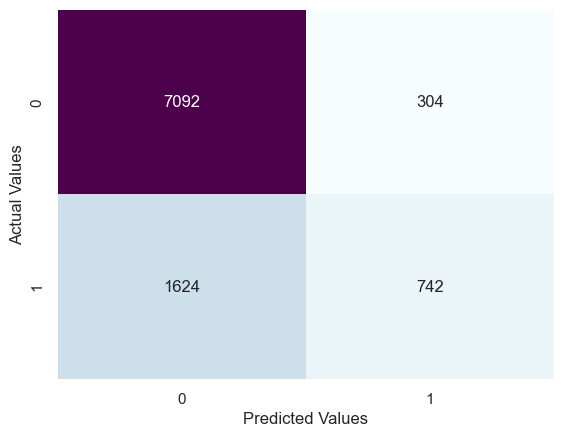

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.71      0.31      0.43      2366

    accuracy                           0.80      9762
   macro avg       0.76      0.64      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.802499487809875


In [66]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()
 
 
print("Classification report:")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [68]:
classifier=LogisticRegression()
 
#performing kfold_cross_validation
from sklearn.model_selection import StratifiedKFold
kfold_cv=StratifiedKFold(n_splits=10,random_state=10,shuffle=True)
#print(kfold_cv)
 
from sklearn.model_selection import cross_val_score
#running the model using scoring metric as accuracy
kfold_cv_result=cross_val_score(estimator=classifier,X=X_train,
                                                 y=Y_train, cv=kfold_cv)
print(kfold_cv_result)
#finding the mean
print(kfold_cv_result.mean())

[0.80377524 0.80904302 0.80421422 0.78884987 0.80377524 0.80456741
 0.80544576 0.80939833 0.80851998 0.80193237]
0.8039521450331849


In [70]:
#model tuning
for train_value, test_value in kfold_cv.split(X_train, Y_train):
    classifier.fit(X_train[train_value], Y_train[train_value]).predict(X_train[test_value])
 
Y_pred=classifier.predict(X_test)
#print(list(zip(Y_test,Y_pred)))

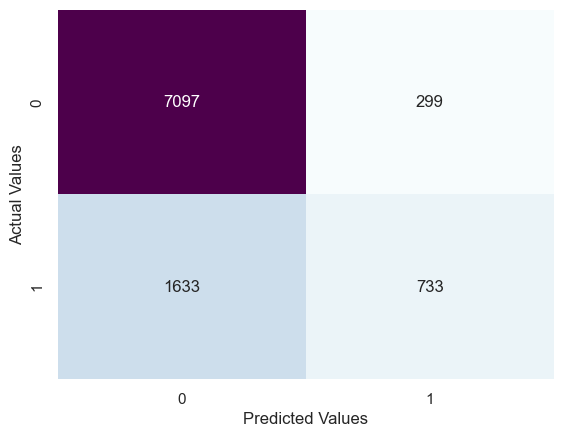

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.71      0.31      0.43      2366

    accuracy                           0.80      9762
   macro avg       0.76      0.63      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.8020897357098955


In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()
 
 
print("Classification report:")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [ ]:
# Feature selection using Recursive Feature Elimination:

In [80]:
X=adult_df_rev.values[:,:-1]
Y=adult_df_rev.values[:,-1]

In [81]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)
print(X)

[[ 0.03038995  2.62344898 -0.33526611 ... -0.21674317 -0.03566374
   0.26113115]
 [ 0.8369732   1.72054053 -0.33526611 ... -0.21674317 -2.22248299
   0.26113115]
 [-0.0429358  -0.08527638  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]
 ...
 [ 1.42357919 -0.08527638  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]
 [-1.2161478  -0.08527638  0.18151876 ... -0.21674317 -1.65552985
   0.26113115]
 [ 0.9836247   0.81763207  0.18151876 ... -0.21674317 -0.03566374
   0.26113115]]


In [82]:
from sklearn.model_selection import train_test_split
# split the data into test and train 
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=10)

In [83]:
from sklearn.linear_model import LogisticRegression
# create a model
classifier=LogisticRegression()

In [84]:
colname=adult_df_rev.columns

In [85]:
from sklearn.feature_selection import RFE
rfe = RFE(classifier, n_features_to_select=7)
model_rfe = rfe.fit(X_train, Y_train)
print("Num Features: ",model_rfe.n_features_)
print("Selected Features: ")
print(list(zip(colname, model_rfe.support_)))
print("Feature Ranking: ", model_rfe.ranking_)

Num Features:  7
Selected Features: 
[('age', np.True_), ('workclass', np.False_), ('education', np.True_), ('occupation', np.False_), ('relationship', np.True_), ('race', np.False_), ('sex', np.True_), ('capital_gain', np.True_), ('capital_loss', np.True_), ('hours_per_week', np.True_), ('native_country', np.False_)]
Feature Ranking:  [1 3 1 4 1 2 1 1 1 1 5]


In [86]:
Y_pred=model_rfe.predict(X_test)

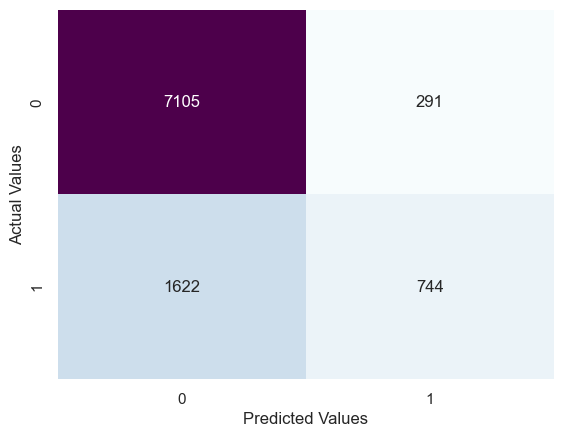

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      7396
           1       0.72      0.31      0.44      2366

    accuracy                           0.80      9762
   macro avg       0.77      0.64      0.66      9762
weighted avg       0.79      0.80      0.77      9762

Accuracy of the model:  0.8040360581847982


In [87]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()
 
 
print("Classification report:")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [88]:
new_data=adult_df_rev[['age','workclass','occupation','sex','capital_gain','hours_per_week','income']]
new_data.head()
new_X=new_data.values[:,:-1]
new_Y=new_data.values[:,-1]
print(new_X)
print(new_Y)
 
#in case the RFE eliminates logically relevant variables, create a  new df manually by subsetting the variables derived from RFE as well as on the basis of domain knowledge.
#rest of the model building steps will have to be performed manually

[[   39     6     0     1  2174    40]
 [   50     5     3     1     0    13]
 [   38     3     5     1     0    40]
 ...
 [   58     3     0     0     0    40]
 [   22     3     0     1     0    20]
 [   52     4     3     0 15024    40]]
[0 0 0 ... 0 0 1]
